# 🎯 03 — BERT Fine-Tuning: İstanbul Intent Detection

6 intent sınıfı için BERT modeli fine-tuning yapılır.

| Label | Intent | Örnek |
|-------|--------|-------|
| 0 | `tarih_ve_kultur` | "Ayasofya ne zaman yapıldı?" |
| 1 | `ulasim_ve_seyahat` | "Metrobüs nerede?" |
| 2 | `yemek_ve_gastronomi` | "İstanbul'da ne yenir?" |
| 3 | `cografya_ve_semt` | "Boğaz ne kadar uzun?" |
| 4 | `egitim_ve_is` | "Boğaziçi Üniversitesi nerede?" |
| 5 | `spor_ve_eglence` | "Galatasaray hangi kupayı aldı?" |

## 📊 Adım 1: Veri Setini İncele

Toplam örnek: 133
Sinif sayisi: 6

intent
tarih_ve_kultur        25
ulasim_ve_seyahat      23
cografya_ve_semt       22
spor_ve_eglence        22
yemek_ve_gastronomi    21
egitim_ve_is           20
Name: count, dtype: int64


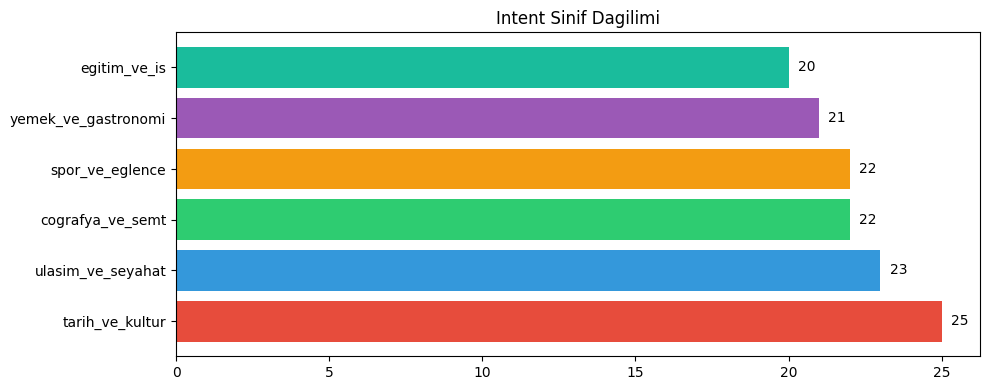

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from data.intent_dataset import RAW_DATA, INTENT_LABELS, LABEL_TO_ID

df = pd.DataFrame(RAW_DATA, columns=['metin', 'intent'])
df['label_id'] = df['intent'].map(LABEL_TO_ID)

print(f'Toplam örnek: {len(df)}')
print(f'Sinif sayisi: {df["intent"].nunique()}')
print()
print(df['intent'].value_counts())

fig, ax = plt.subplots(figsize=(10, 4))
counts = df['intent'].value_counts()
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
bars = ax.barh(counts.index, counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, str(val), va='center')
ax.set_title('Intent Sinif Dagilimi')
plt.tight_layout()
plt.savefig('intent_distribution.png', dpi=120)
plt.show()

## ✂️ Adım 2: Train/Test Split

In [2]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_id'], random_state=42)
print(f'Train: {len(train_df)} ornek')
print(f'Test : {len(test_df)} ornek')

Train: 106 ornek
Test : 27 ornek


## 🧠 Adım 3: BERT Modeli Hazirla

In [3]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ON_CPU = (device.type == 'cpu')
print(f'Cihaz: {device}')
if ON_CPU:
    print('GPU yok -> CPU modunda calisiliyor (yavas olabilir)')

MODEL_NAME = 'dbmdz/bert-base-turkish-cased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(INTENT_LABELS),
    id2label={i: l for i, l in enumerate(INTENT_LABELS)},
    label2id=LABEL_TO_ID
).to(device)
print('✅ Turkish BERT modeli yuklendi!')

c:\Users\Casper\Desktop\for projects\proje_gelistirme\chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cihaz: cpu
GPU yok -> CPU modunda calisiliyor (yavas olabilir)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2209.81it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from 

✅ Turkish BERT modeli yuklendi!


## 📦 Adım 4: Dataset & DataLoader

In [4]:
class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['metin'].tolist()
        self.labels = df['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = IntentDataset(train_df, tokenizer)
test_ds  = IntentDataset(test_df, tokenizer)

BATCH = 8 if ON_CPU else 16
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=BATCH)
print(f'✅ Train loader: {len(train_dl)} batch')

✅ Train loader: 14 batch


## 🚀 Adım 5: Fine-Tuning

In [5]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm

EPOCHS = 3 if not ON_CPU else 2
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_dl) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

loss_history = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_dl, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dl)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1} — Ortalama Loss: {avg_loss:.4f}')

Epoch 1/2:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 1/2: 100%|██████████| 14/14 [02:00<00:00,  8.60s/it]


Epoch 1 — Ortalama Loss: 1.8605


Epoch 2/2: 100%|██████████| 14/14 [01:19<00:00,  5.70s/it]

Epoch 2 — Ortalama Loss: 1.7205


## 📈 Adım 6: Degerlendirme

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_dl:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(batch['labels'].numpy())

print('=== Classification Report ===')
print(classification_report(all_true, all_preds, target_names=INTENT_LABELS))

=== Classification Report ===
                     precision    recall  f1-score   support

    tarih_ve_kultur       0.29      1.00      0.45         5
  ulasim_ve_seyahat       0.00      0.00      0.00         5
yemek_ve_gastronomi       0.75      0.75      0.75         4
   cografya_ve_semt       0.67      0.40      0.50         5
       egitim_ve_is       0.00      0.00      0.00         4
    spor_ve_eglence       0.00      0.00      0.00         4

           accuracy                           0.37        27
          macro avg       0.29      0.36      0.28        27
       weighted avg       0.29      0.37      0.29        27



c:\Users\Casper\Desktop\for projects\proje_gelistirme\chatbot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Casper\Desktop\for projects\proje_gelistirme\chatbot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Casper\Desktop\for projects\proje_gelistirme\chatbot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

## 💾 Adım 7: Modeli Kaydet

In [7]:
import os
os.makedirs('model/istanbul_intent', exist_ok=True)
model.save_pretrained('model/istanbul_intent')
tokenizer.save_pretrained('model/istanbul_intent')
print('✅ Model kaydedildi: model/istanbul_intent')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.55it/s]

✅ Model kaydedildi: model/istanbul_intent
